# Using Qrisp circuits with Topologiq

In [1]:
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

This notebook offers an example of how to use ***Topologiq*** to perform algorithmic lattice surgery on Qrisp circuit.

The notebook is unfinished. 

The idea is to add more circuits at a later point in time. 

Contributions welcome!

# HT sequence

Let's start by creating an HT (times *n*) circuit using Qrisp.

In [2]:
from qrisp import QuantumVariable, h, t

# Give circuit a catchy name
circuit_name = "qrisp_ht_sequence"

# Number of HT sequences in circuit
n = 10

# Create a Quantum Variable of 1 single qubit
qrisp_circuit = QuantumVariable(1)

# Add gates
for _ in range(n):
    h(qrisp_circuit[0])
    t(qrisp_circuit[0])

# Visualise
print(qrisp_circuit.qs)

QuantumCircuit:
---------------
                 ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
qrisp_circuit.0: ┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ T ├»
                 └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«                 ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐
«qrisp_circuit.0: ┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ T ├┤ H ├┤ T ├
«                 └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘
Live QuantumVariables:
----------------------
QuantumVariable qrisp_circuit


The next step is to bring the circuit into Topologiq's general workflow and convert it into PyZX. 

There's a hard and an easy way to do this.
- Hard way: convert the Qrisp circuit to QASM using native Qrisp methods, then import to PyZX using native PyZX methods, then feed into Topologiq.
- Easy way: convert Qrisp circuit to Qiskit, then use Topologiq's circuit and ZX graph manager to navigate all other conversions. 

We'll go the easy way here.

In [3]:
import pyzx as zx
from topologiq.input.circuit_manager import CircuitManager
from topologiq.input.zx_manager import ZXGraphManager

# -> Qiskit
qc = qrisp_circuit.qs.to_qiskit()

# -> QASM
circuit_manager = CircuitManager()
qasm_str = circuit_manager.add_qiskit_circuit(qc, key="qrisp_circuit")

# KWARGs
kwargs = {
    "first_id_strategy": "centrality-majority",
    "debug": 1,
    "graph_traverse_mode": "tfs",
    "z_stretch": 3,
    "twins": False
}

# QASM -> ZX manager
zx_graph_manager = ZXGraphManager()
augmented_zx_graph = zx_graph_manager.add_graph_from_qasm(
    qasm_str=qasm_str, graph_key=circuit_name
)
zx.draw(augmented_zx_graph.zx_graph, labels=True)


=> Ingesting PyZX graph.


Time for ***Topologiq*** to do its thing. We just call a `BlockGraphManager` on the `augmented_zx_graph` and use its methods.


=> Building BlockGraph.
* First cube.
  - Completed. ID: 0. Kind: OOO, Coords: (0, 0, 0).
* Edge: 0 (O) --> 2 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.01s
* Edge: 2 (Z) --> 4 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.00s
* Edge: 4 (Z) --> 6 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.00s
* Edge: 6 (Z) --> 8 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.00s
* Edge: 8 (Z) --> 10 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.00s
* Edge: 10 (Z) --> 12 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.00s
* Edge: 12 (Z) --> 14 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.00s
* Edge: 14 (Z) --> 16 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.00s
* Edge: 16 (Z) --> 18 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.00s
* Edge: 18 (Z) --> 20 (Z). STANDARD
  - Completed. Vol +: 4. Duration: 0.00s
* Edge: 20 (Z) --> 21 (O). STANDARD
  - Completed. Vol +: 3. Duration: 0.39s
* Edge: 2 (Z) --> 22 (Z). STANDARD
  - Completed. Vol +: 1. Duration: 0

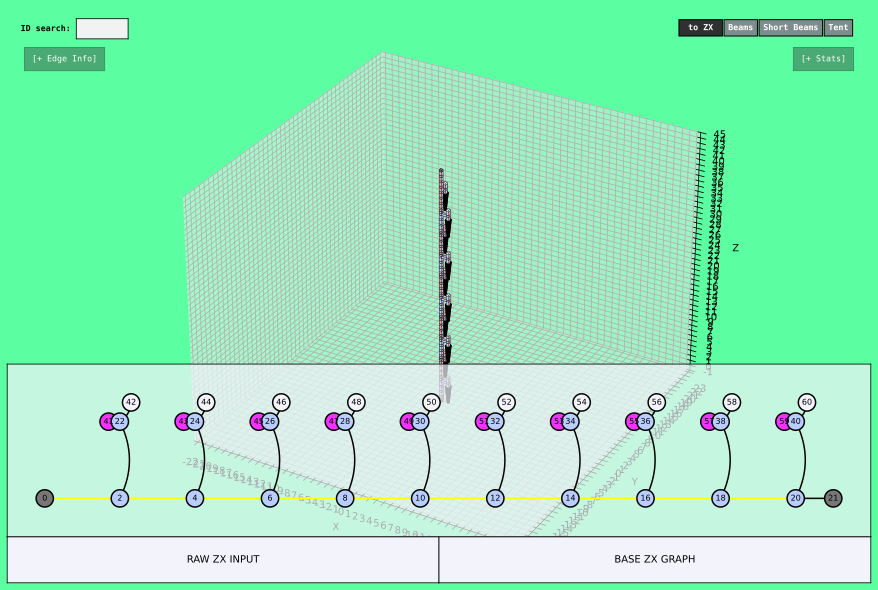

In [4]:
from topologiq.core.graph_manager.graph_manager import BlockGraphManager

# AugmentedZXGraph -> BlockGraph
bgraph_manager = BlockGraphManager(augmented_zx_graph, **kwargs)
bgraph_manager.build()
bgraph_manager.draw_blockgraph()

Optionally, you can write results to a BGRAPH file.

In [5]:
bgraph_manager.write_bgraph(circuit_name=circuit_name)